## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV


In [142]:
data = pd.read_csv('penguins_data.csv')
data.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [ ]:
print(f"Число пропусков в data: {data.isna().sum().sum()}") # пропуски есть
data.dropna(inplace=True) # теперь нет
print(f"Число пропусков в data после удаления: {data.isna().sum().sum()}")
print(data.select_dtypes(include=['object']).head(10)) # категориальных колонок 3 + таргет
# Были вопросы по уникальным значениям: оказывается в поле Sex есть объект со значением .
# Бог его знает что это значит, но было принято решение столбец оставить

# кодируем one-hot, т.к. тогда расстояния между любыми двумя разными категориями будут одинаковы (в рамках одного признака)
# в отличие, например, от ladel, где создастя искусственный порядок и расстояния для разных значений признака получатся разными
encoded_data = pd.get_dummies(data, columns=["Island", "Clutch Completion", "Sex"], drop_first=True)
encoded_data

Число пропусков в data: 45
Число пропусков в data после удаления: 0
     Species  Island Clutch Completion     Sex
0  Chinstrap   Dream               Yes    MALE
1  Chinstrap   Dream               Yes  FEMALE
2     Gentoo  Biscoe               Yes  FEMALE
3  Chinstrap   Dream               Yes  FEMALE
4     Gentoo  Biscoe               Yes  FEMALE
5     Gentoo  Biscoe               Yes    MALE
6     Gentoo  Biscoe               Yes    MALE
7     Gentoo  Biscoe                No  FEMALE
8     Adelie  Biscoe               Yes  FEMALE
9     Gentoo  Biscoe               Yes  FEMALE


,Species,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Dream,Island_Torgersen,Clutch Completion_Yes,Sex_FEMALE,Sex_MALE
0,Chinstrap,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,True,False,True,False,True
1,Chinstrap,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,True,False,True,True,False
2,Gentoo,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,False,False,True,True,False
3,Chinstrap,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,True,False,True,True,False
4,Gentoo,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,Chinstrap,382,47.6,18.3,195.0,3850.0,8.83502,-24.65859,True,False,True,True,False
340,Adelie,382,39.7,18.4,190.0,3900.0,9.29808,-25.23453,False,True,True,False,True
341,Adelie,16,38.6,17.2,199.0,3750.0,8.77322,-26.48973,False,False,True,True,False
342,Gentoo,392,46.6,14.2,210.0,4850.0,8.38289,-26.86352,False,False,True,True,False


Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [144]:
encoder_tg = OrdinalEncoder(categories=[["Chinstrap", "Gentoo", "Adelie"]])
encoded_data["Species_Encoded"] = encoder_tg.fit_transform(encoded_data[["Species"]])
print(encoded_data.head(5)) # наблюдаем

X = encoded_data.drop(["Species", "Species_Encoded"], axis=1, inplace=False)
y = encoded_data["Species_Encoded"]


     Species  Date Egg  Culmen Length (mm)  Culmen Depth (mm)  \
0  Chinstrap       382                50.9               19.1   
1  Chinstrap       741                45.2               17.8   
2     Gentoo       744                46.5               13.5   
3  Chinstrap        10                45.2               16.6   
4     Gentoo        13                48.4               14.4   

   Flipper Length (mm)  Body Mass (g)  Delta 15 N (o/oo)  Delta 13 C (o/oo)  \
0                196.0         3550.0           10.02372          -24.86594   
1                198.0         3950.0            8.88942          -24.49433   
2                210.0         4550.0            7.99530          -25.32829   
3                191.0         3250.0            9.62357          -24.78984   
4                203.0         4625.0            8.16582          -26.13971   

   Island_Dream  Island_Torgersen  Clutch Completion_Yes  Sex_FEMALE  \
0          True             False                   True      

**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [145]:
np.random.seed(67)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=67, stratify=y)
# stratify важно использовать чтобы сохранить пропорции классов
# (чтобы какой-то малочисленный вид пингвинов не исчез из train или test)
# + если какой-то малочисленный класс исчезнет из train, то мы не сможем корректно обучить модель

**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [ ]:
'''
Ссылки на источники:
sklearn.metrics.accuracy_score() - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
'''

scaler = StandardScaler()
scaled_X_train = pd.DataFrame(scaler.fit_transform(X_train[["Flipper Length (mm)", "Body Mass (g)"]]))
scaled_X_test = pd.DataFrame(scaler.fit_transform(X_test[["Flipper Length (mm)", "Body Mass (g)"]]))

k_vars = [1, 3, 5, 10, 15, 25]
clf_lst = []

print("NN\tTrain\tTest")
for k in k_vars:
    neigh = KNeighborsClassifier(n_neighbors=k) # создали
    neigh.fit(scaled_X_train, y_train) # обучили
    clf_lst.append(neigh)
    y_predicted_train = neigh.predict(scaled_X_train)
    y_predicted_test = neigh.predict(scaled_X_test)
    acc_train = accuracy_score(y_train, y_predicted_train)
    acc_test = accuracy_score(y_test, y_predicted_test)
    print(f"{k}\t{acc_train:.2f}\t{acc_test:.2f}")


NN	Train	Test
1	0.97	0.73
3	0.90	0.76
5	0.87	0.74
10	0.85	0.76
15	0.85	0.77
25	0.85	0.74


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [8]:
!pip install mlxtend

^C


Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [72]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

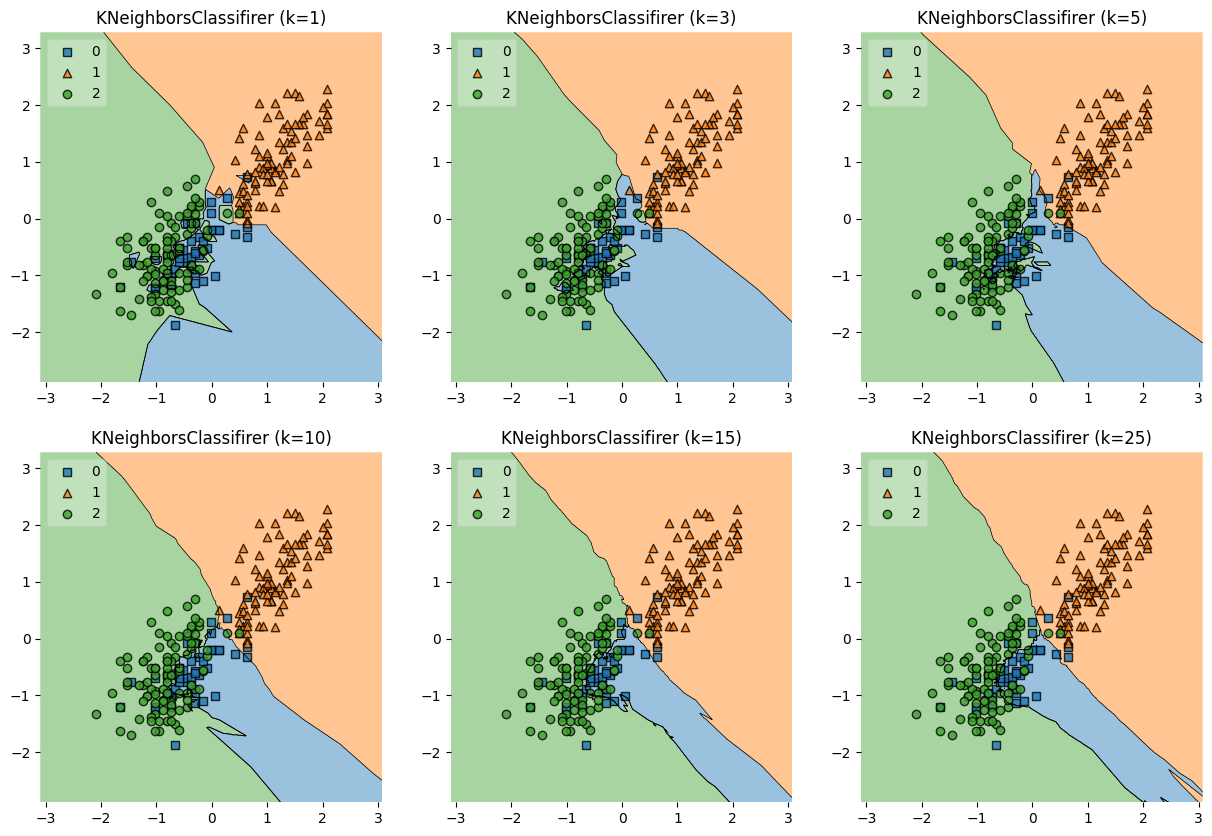

In [156]:
# В примере пингвинчики закодированы в алфавитном порядке, ваш вариант будет отличаться.
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools

gs = gridspec.GridSpec(2, 3)
fig = plt.figure(figsize=(15,10))
for clf, k, grd in zip(clf_lst,
                         k_vars,
                         itertools.product([0, 1, 2], repeat=2)):
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(X=scaled_X_train.to_numpy(), y=y_train.to_numpy().astype(int), clf=clf, legend=2)
    plt.title(f'KNeighborsClassifirer (k={k})')

plt.show()

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

In [ ]:
'''
Результат из задачи 3.1

NN	Train	Test
1	0.97	0.73
3	0.9	    0.76
5	0.87	0.74
10	0.85	0.76
15	0.85	0.77
25	0.85	0.74
'''
'''
Явное переобучение наблюдается при k=1, т.к.
    1) На графике выделяются "островки" для некоторых объектов (аналогично для k=2 и k=3 -> слишком маленькое число соседей)
    2) Очень хороший результат на тренировочной выборке и сильно хуже на тестовой
k=2 и k=3 также не подойдут (см пункт 1)
Для k=15 и k=25 границы между классами на графиках становятся очень "пологими" - некоторые достаточно большие группы объектов оказываются определены к другоиу классу
Оптимальным является k=10 - нет сильных выбросов (в отличие от маленьких k) и достаточно хороший результат для тестовой выборки
'''

### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

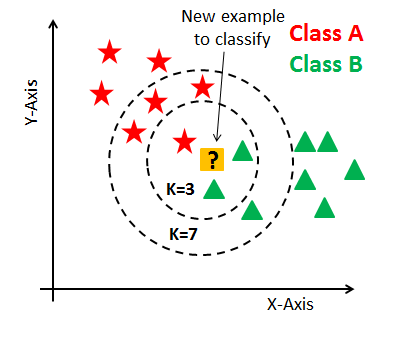

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [157]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k:int):
        if k <= 0:
          raise ValueError("k must be positive")
        self.k = k

    def fit(self, X, y):
      # (⌒_⌒;)
      if X.shape[0] != y.shape[0]:
        raise ValueError("Number of objects in x and y must be the same")
      if X.shape[0] < self.k:
        raise ValueError("Too little data for current k")
      self.X_train = X
      self.y_train = y

    def predict(self, X):
      # (＠_＠)
      y = []
      for x in X:
        distances = [self.count_distance(x, x_train) for x_train in self.X_train]
        sorted_inds = np.argsort(distances)
        k_inds = sorted_inds[:self.k]
        k_classes = self.y_train[k_inds]
        most_common = Counter(k_classes).most_common(1)[0][0]
        y.append(most_common)
      return np.array(y)

    def count_distance(self, x, y):
      # ヽ(♡‿♡)ノ
      return np.linalg.norm(x - y)


In [158]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [159]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [162]:
k_vars = [1, 3, 5, 10, 15, 25]

best_k = 0
best_accuracy = 0

print("NN\tAccuracy")
for k in k_vars:
    neigh = KNN(k) # создали
    neigh.fit(scaled_X_train.values, y_train.values) # обучили

    y_predicted_test = neigh.predict(scaled_X_test.values)
    accuracy = accuracy_score(y_test.values, y_predicted_test)
    print(f"{k}\t{accuracy}")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_k = k

print(f"Лучшее k: {best_k} с долей верных ответов {best_accuracy:.4f} на test.") # всё-таки не точность




NN	Accuracy
1	0.7142857142857143
3	0.7551020408163265
5	0.7448979591836735
10	0.7653061224489796
15	0.7653061224489796
25	0.7448979591836735
Лучшее k: 10 с долей верных ответов 0.7653 на test.


### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [163]:
data = pd.read_csv('diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [164]:
print(f"Число пропусков в data: {data.isna().sum().sum()}") # пропусков нет
data = data.drop(["Unnamed: 0"], axis=1) # Unnamed: 0 - поярдковая нумерация, остальное в целом информативно

Число пропусков в data: 0


**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

In [165]:
numeric = ["carat", "depth", "table", "x", "y", "z"]

data[numeric + ["price"]].corr()
# carat имеет наибольшую корреляцию, также хорошую корреляцию имеют x, y и z

,carat,depth,table,x,y,z,price
carat,1.000000,0.028224,0.181618,0.975094,0.951722,0.953387,0.921591
depth,0.028224,1.000000,-0.295779,-0.025289,-0.029341,0.094924,-0.010647
table,0.181618,-0.295779,1.000000,0.195344,0.183760,0.150929,0.127134
x,0.975094,-0.025289,0.195344,1.000000,0.974701,0.970772,0.884435
y,0.951722,-0.029341,0.183760,0.974701,1.000000,0.952006,0.865421
z,0.953387,0.094924,0.150929,0.970772,0.952006,1.000000,0.861249
price,0.921591,-0.010647,0.127134,0.884435,0.865421,0.861249,1.000000


**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [166]:
encoded_data = pd.get_dummies(data, columns=["cut", "color", "clarity"], drop_first=True)
encoded_data

,carat,depth,table,price,x,y,z,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,False,False,True,...,False,True,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,True,False,False,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,5.75,5.76,3.50,False,True,False,...,False,False,False,False,True,False,False,False,False,False
53936,0.72,63.1,55.0,2757,5.69,5.75,3.61,True,False,False,...,False,False,False,False,True,False,False,False,False,False
53937,0.70,62.8,60.0,2757,5.66,5.68,3.56,False,False,False,...,False,False,False,False,True,False,False,False,False,False
53938,0.86,61.0,58.0,2757,6.15,6.12,3.74,False,False,True,...,True,False,False,False,False,True,False,False,False,False


**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

In [167]:
np.random.seed(52)
X = encoded_data.drop(["price"], axis=1, inplace=False)
y = encoded_data["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=52)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [168]:
scaler = StandardScaler()

scaled_X_train = pd.DataFrame(scaler.fit_transform(X_train))
scaled_X_test = pd.DataFrame(scaler.fit_transform(X_test))

# На что повлияет масштабирование:
#   1) До масштабирования коэффициенты при признаках с более высокими весами не показывают, насколько важен тот или иной признак для предсказания результата
#      после масштабирования коэффициенты при признаках позволяют понять "важность" (из-за одинакового масштаба)
#   2) Влияет на штрафы при регуляризации: нет несправедливого наказания за большие коэффициенты при маленьких признаках

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [171]:
reg = LinearRegression().fit(scaled_X_train, y_train)

mse_train = mean_squared_error(y_train, reg.predict(scaled_X_train))
mse_test = mean_squared_error(y_test, reg.predict(scaled_X_test))
print(f"MSE на train: {mse_train}")
print(f"MSE на test: {mse_test}")

MSE на train: 1283859.0683540818
MSE на test: 1266330.733279263


**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [172]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': reg.coef_
})
print(coef_df.sort_values(by="coefficient")) # для всех переменных
print()
numeric = ["carat", "depth", "table", "x", "y", "z"]
print(coef_df[coef_df['feature'].isin(numeric)].sort_values(by="coefficient")) # для вещественных
# Среди всех переменных выделяются: carat, всё связанное с clarity, x
# Среди вещественных переменных выделяются: carat, x

          feature  coefficient
3               x -1075.771486
15        color_J  -520.238479
14        color_I  -435.510982
13        color_H  -347.033625
12        color_G  -195.376495
11        color_F  -103.901198
1           depth   -96.275606
10        color_E   -78.075481
2           table   -65.808786
5               z   -28.767314
4               y     0.798339
6        cut_Good   179.907565
9   cut_Very Good   316.230404
8     cut_Premium   348.480241
7       cut_Ideal   422.516718
16     clarity_IF   946.535790
18    clarity_SI2  1033.534214
21   clarity_VVS1  1252.299724
22   clarity_VVS2  1465.591843
17    clarity_SI1  1581.863013
19    clarity_VS1  1655.213269
20    clarity_VS2  1805.978020
0           carat  5279.547975

  feature  coefficient
3       x -1075.771486
1   depth   -96.275606
2   table   -65.808786
5       z   -28.767314
4       y     0.798339
0   carat  5279.547975


**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [175]:
alpha = 10
reg_lasso = Lasso(alpha=alpha).fit(scaled_X_train, y_train)

lasso_coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': reg_lasso.coef_
})

lasso_coef_df.sort_values(by="coefficient")

# Веса действительно уменьшились, для y вес занулился (признак не важен или его влияние учтено в других признаках)


,feature,coefficient
3,x,-610.885045
15,color_J,-462.210355
14,color_I,-362.514329
13,color_H,-273.505726
12,color_G,-118.309965
1,depth,-100.911840
2,table,-76.615382
11,color_F,-36.572583
5,z,-30.817093
10,color_E,-7.495949


In [176]:
reg_ridge = Ridge(alpha=alpha).fit(scaled_X_train, y_train)

ridge_coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': reg_ridge.coef_
})

ridge_coef_df.sort_values(by="coefficient")
# Веса практически не уменьшились, но слегка перераспределились веса у признаков с сильной корреляцией (x, y, z и carat)
# -> Можно сказать о проблеме мультиколлинеарности для признаков x, y, z и carat

,feature,coefficient
3,x,-1033.359139
15,color_J,-519.000309
14,color_I,-434.159820
13,color_H,-346.089556
12,color_G,-194.861422
11,color_F,-103.676794
1,depth,-94.380776
10,color_E,-77.629167
2,table,-65.965920
5,z,-32.609629


**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

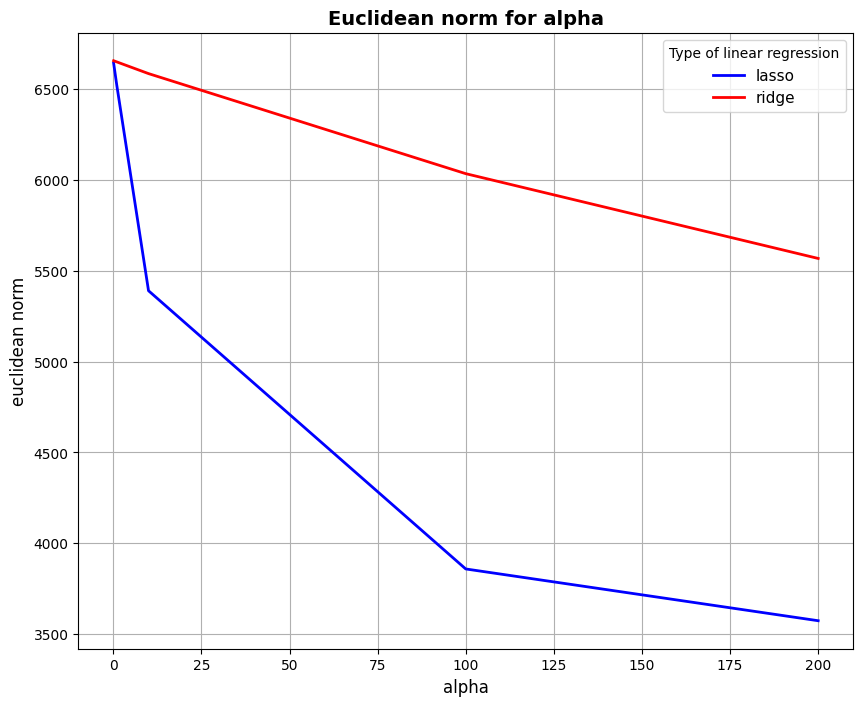

In [ ]:
alphas = [0.1, 1, 10, 100, 200]
norms_lasso = []
norms_ridge = []

for alph in alphas:
    reg_lasso = Lasso(alph).fit(scaled_X_train, y_train)
    reg_ridge = Ridge(alph).fit(scaled_X_train, y_train)

    norms_lasso.append(np.linalg.norm(reg_lasso.coef_))
    norms_ridge.append(np.linalg.norm(reg_ridge.coef_))


plt.figure(figsize=(10, 8))

plt.plot(alphas, norms_lasso, 'b-', linewidth=2, label='lasso')
plt.plot(alphas, norms_ridge, 'r-', linewidth=2, label='ridge')

plt.xlabel('alpha', fontsize=12)
plt.ylabel('euclidean norm', fontsize=12)

plt.title('Euclidean norm for alpha', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11, title='Type of linear regression')
plt.grid()

plt.show()
# Норму сильнее снижает Lasso
# Причина: Lasso зануляет признаки, которые слабо коррелируют с целевой переменной или сильно коррелируют с другими признаками (их влияние учитывается в других признаках)

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [179]:
alphas = [0.1, 1, 10, 100, 200]

reg_lasso_cv = LassoCV(cv=5, alphas=alphas, random_state=34).fit(scaled_X_train, y_train) # iconic чисел не осталось больше
alphas_reg = reg_lasso_cv.alphas_
mse_means = reg_lasso_cv.mse_path_.mean(axis=1)

print("alpha\tmse_mean")
for alph, mse_mean in zip(alphas_reg, mse_means):
    print(f"{alph}\t{mse_mean.round(2)}")

print()
print(f"Значение, которое даёт наибольшее качество: alpha = {reg_lasso_cv.alpha_}")

alpha	mse_mean
200.0	2163593.08
100.0	1800082.03
10.0	1347579.64
1.0	1288874.95
0.1	1288422.37

Значение, которое даёт наибольшее качество: alpha = 0.1


**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [180]:
reg_lasso_finally = Lasso(alpha=0.1).fit(scaled_X_train, y_train)

lasso_finally_coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': reg_lasso_finally.coef_
})

lasso_finally_coef_df.sort_values(by="coefficient")
# Наиболее информативный признак - carat, т.к. чем больше вес бриллианта тем обычно выше его цена
# Чуть менее информативные, но всё ещё важные - признаки, связаные с clarity (чем чище камень и чем меньше в нём включений, тем он дороже)
# Также из важных: цвет (чем выше тем дешевле)
# Неважными оказались: y, z, table, color_E, depth
# y и z оказались неинформативными, так как их влияние уже учтено в carat и x

,feature,coefficient
3,x,-1070.490897
15,color_J,-519.658080
14,color_I,-434.781000
13,color_H,-346.297346
12,color_G,-194.605989
11,color_F,-103.227527
1,depth,-96.342803
10,color_E,-77.369178
2,table,-65.920980
5,z,-28.673091


**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.6. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [181]:
mse_test = mean_squared_error(y_test, reg_lasso_finally.predict(scaled_X_test))
print(f"MSE на test: {mse_test}")
# MSE на test для linreg: 1266330.733279263
# MSE для Lasso всё-таки чуть-чуть лучше, поэтому для предсказаний следует использовать именно её
# Lasso лучше, потому что её предсказания имеют бОльшую зависимость от важных признаков, а неважные "отбрасываются", тогда как в обычной регрессии влияние "размазано" примерно по всем признакам

MSE на test: 1266303.5744565018
